# Phase 5: Advanced Risk Management

Risk management is arguably **more important than signal generation**. A mediocre strategy with excellent risk management will survive; a great strategy with poor risk management will blow up.

This notebook covers:
1. **Value at Risk (VaR)**: How much could I lose on a bad day?
2. **Position Sizing**: How much should I bet on each trade?
3. **Adaptive Stop Loss**: Stops that adjust to volatility
4. **Circuit Breakers**: Automatic trading halt when things go wrong

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.loader import HistoricalDataLoader
from src.data.preprocessor import clean_data
from src.risk.position_sizing import PositionSizer
from src.risk.stop_loss import AdaptiveStopLoss
from src.risk.circuit_breakers import CircuitBreaker, RiskLimits, PortfolioState
from src.risk.risk_metrics import RiskAnalyzer

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Setup complete!")

Setup complete!


In [2]:
# Load real data
loader = HistoricalDataLoader(cache_dir="../../data/cache")
df = clean_data(loader.load_pair("USD/JPY", start="2021-01-01", end="2024-12-31", interval="1d"))
returns = df['close'].pct_change().dropna()
print(f"Loaded {len(df)} bars")

Loaded 1042 bars


## 1. Value at Risk (VaR)

VaR answers the question: **"How much could I lose on a bad day?"**

- **VaR 95%**: The loss you won't exceed 95% of the time
- **VaR 99%**: The loss you won't exceed 99% of the time

Example: If your VaR 95% is $10,000, it means:
- 95% of days, you'll lose less than $10,000
- 5% of days (about once a month), you could lose MORE

### Conditional VaR (CVaR / Expected Shortfall)

VaR tells you the threshold, but what happens when you cross it?

CVaR is the **average loss when you exceed VaR**. It captures tail risk.

In [3]:
analyzer = RiskAnalyzer()
portfolio_value = 100000

var_95 = analyzer.historical_var(returns, confidence=0.95, portfolio_value=portfolio_value)
var_99 = analyzer.historical_var(returns, confidence=0.99, portfolio_value=portfolio_value)

print(f"Portfolio: ${portfolio_value:,}")
print(f"\n95% Confidence (expect to exceed ~12 days/year):")
print(f"  VaR:  ${var_95.var:,.0f} ({var_95.var_pct:.2%})")
print(f"  CVaR: ${var_95.cvar:,.0f} ({var_95.cvar_pct:.2%})")
print(f"\n99% Confidence (expect to exceed ~2.5 days/year):")
print(f"  VaR:  ${var_99.var:,.0f} ({var_99.var_pct:.2%})")
print(f"  CVaR: ${var_99.cvar:,.0f} ({var_99.cvar_pct:.2%})")

Portfolio: $100,000

95% Confidence (expect to exceed ~12 days/year):
  VaR:  $939 (0.94%)
  CVaR: $1,433 (1.43%)

99% Confidence (expect to exceed ~2.5 days/year):
  VaR:  $1,653 (1.65%)
  CVaR: $2,194 (2.19%)


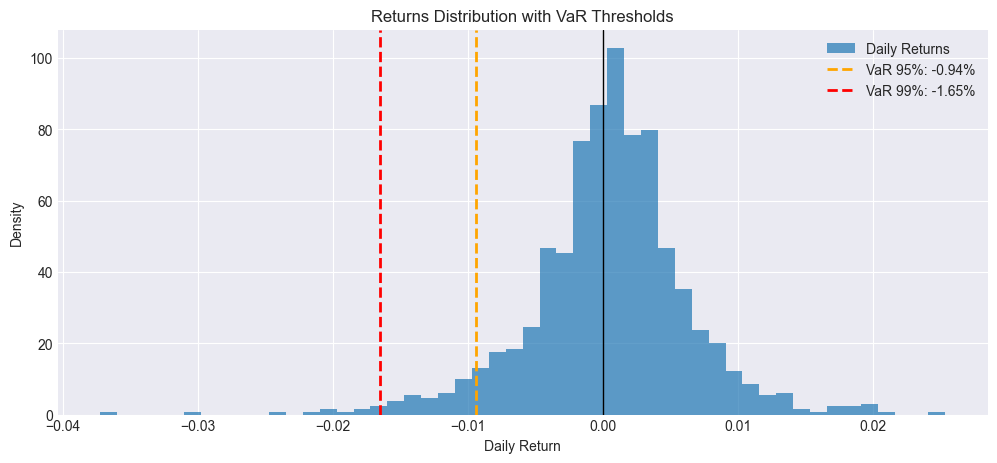

In [4]:
# Visualize where VaR sits in the returns distribution
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(returns, bins=50, alpha=0.7, density=True, label='Daily Returns')
ax.axvline(-var_95.var_pct, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: -{var_95.var_pct:.2%}')
ax.axvline(-var_99.var_pct, color='red', linestyle='--', linewidth=2, label=f'VaR 99%: -{var_99.var_pct:.2%}')
ax.axvline(0, color='black', linewidth=1)

ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.set_title('Returns Distribution with VaR Thresholds')
ax.legend()
plt.show()

### VaR Calculation Methods

Three ways to calculate VaR:

1. **Historical**: Use actual past returns (what we just did)
2. **Parametric**: Assume returns are normally distributed (faster, less accurate)
3. **Monte Carlo**: Simulate thousands of scenarios (most accurate, slowest)

In [5]:
# Compare the three methods
hist_var = analyzer.historical_var(returns, 0.95, portfolio_value)
param_var = analyzer.parametric_var(returns, 0.95, portfolio_value)
mc_var = analyzer.monte_carlo_var(returns, 0.95, portfolio_value, n_simulations=10000)

print("VaR 95% Comparison:")
print(f"  Historical:   ${hist_var.var:,.0f}")
print(f"  Parametric:   ${param_var.var:,.0f}")
print(f"  Monte Carlo:  ${mc_var.var:,.0f}")
print(f"\nNote: Parametric often underestimates because markets aren't normally distributed.")

VaR 95% Comparison:
  Historical:   $939
  Parametric:   $941
  Monte Carlo:  $960

Note: Parametric often underestimates because markets aren't normally distributed.


## 2. Position Sizing

Position sizing answers: **"How much should I risk on this trade?"**

Three methods:

### Kelly Criterion
Mathematically optimal sizing that maximizes long-term wealth growth.

$$f^* = \frac{p \cdot b - q}{b}$$

Where:
- p = win probability
- q = loss probability (1-p)
- b = win/loss ratio

**Problem**: Full Kelly is too aggressive. Use **1/4 Kelly** for safety.

### Fixed Fractional
Risk a fixed percentage of capital on each trade.

$$\text{Position} = \frac{\text{Capital} \times \text{Risk\%}}{\text{Stop Distance}}$$

### Volatility-Based
Size inversely proportional to current volatility. When markets are choppy, bet smaller.

In [6]:
sizer = PositionSizer(
    max_position_pct=0.20,  # Never more than 20% in one position
    kelly_fraction=0.25,    # Use 1/4 Kelly
    default_risk_pct=0.02,  # Risk 2% per trade
)

# Your historical performance
win_rate = 0.50
avg_win = 0.04  # 4% average winning trade
avg_loss = 0.025  # 2.5% average losing trade

kelly = sizer.kelly_criterion(win_rate, avg_win, avg_loss)

print("Kelly Criterion Analysis:")
print(f"  Win rate:      {win_rate:.0%}")
print(f"  Avg win:       {avg_win:.1%}")
print(f"  Avg loss:      {avg_loss:.1%}")
print(f"  Win/Loss ratio: {avg_win/avg_loss:.2f}")
print(f"\nResults:")
print(f"  Full Kelly:    {kelly.details['full_kelly']:.1%}")
print(f"  1/4 Kelly:     {kelly.size:.1%}")
print(f"  Expected Edge: {kelly.details['expected_edge']:.4f} per trade")

Kelly Criterion Analysis:
  Win rate:      50%
  Avg win:       4.0%
  Avg loss:      2.5%
  Win/Loss ratio: 1.60

Results:
  Full Kelly:    18.7%
  1/4 Kelly:     4.7%
  Expected Edge: 0.0075 per trade


In [7]:
# Compare all three methods
capital = 100000
entry_price = 150.0
stop_distance = 3.0  # $3 stop = 2%
current_atr = 1.5

ff = sizer.fixed_fractional(capital, stop_distance, entry_price, risk_pct=0.02)
vol = sizer.volatility_based(capital, current_atr, entry_price, atr_multiplier=2.0)

print(f"Position Sizing Comparison (${capital:,} capital):")
print(f"\n  Kelly (1/4):        {kelly.size:.1%} of capital")
print(f"  Fixed Fractional:   {ff.size:.1%} of capital")
print(f"  Volatility-Based:   {vol.size:.1%} of capital")

Position Sizing Comparison ($100,000 capital):

  Kelly (1/4):        4.7% of capital
  Fixed Fractional:   20.0% of capital
  Volatility-Based:   20.0% of capital


## 3. Adaptive Stop Loss (ATR-Based)

Fixed percentage stops have a problem:
- In calm markets: 2% stop is too loose
- In volatile markets: 2% stop is too tight

**ATR-based stops adapt** to current market conditions:

$$\text{Stop Distance} = ATR \times \text{Multiplier}$$

ATR (Average True Range) measures recent volatility, so your stop automatically:
- Widens in volatile markets (avoiding whipsaw)
- Tightens in calm markets (protecting profits)

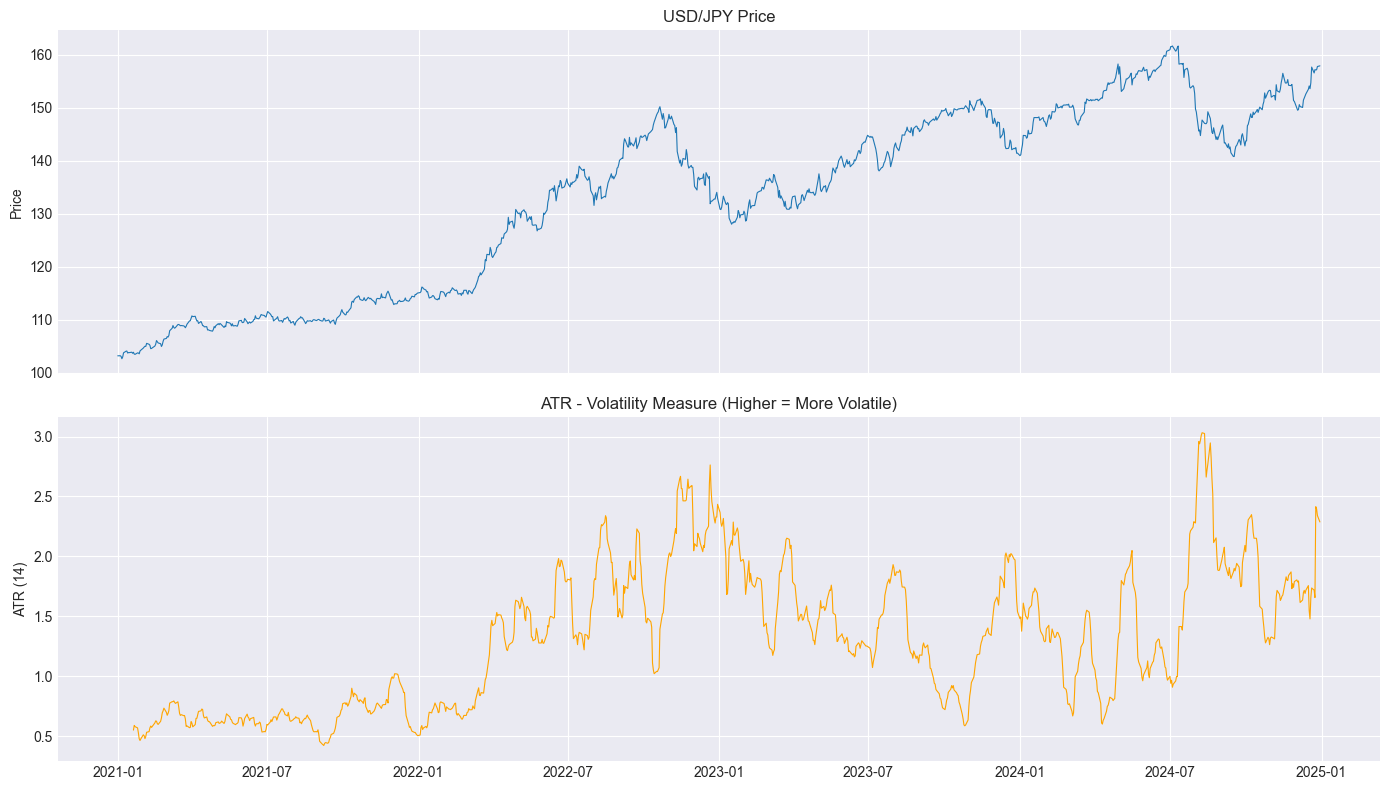

In [8]:
stop_mgr = AdaptiveStopLoss(
    atr_period=14,
    atr_multiplier=2.0,
    trailing_activation_pct=0.02,  # Start trailing after 2% profit
)

# Calculate ATR over time
atr_series = stop_mgr.calculate_atr(df)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df['timestamp'], df['close'], linewidth=0.8)
ax1.set_ylabel('Price')
ax1.set_title('USD/JPY Price')

ax2.plot(df['timestamp'], atr_series, color='orange', linewidth=0.8)
ax2.set_ylabel('ATR (14)')
ax2.set_title('ATR - Volatility Measure (Higher = More Volatile)')

plt.tight_layout()
plt.show()

In [9]:
# Demonstrate initial stop calculation
entry = df['close'].iloc[-1]
current_atr = atr_series.iloc[-1]

stop = stop_mgr.initial_stop(entry_price=entry, is_long=True, atr=current_atr)

print(f"ATR-Based Stop Calculation:")
print(f"  Entry price:   {entry:.2f}")
print(f"  Current ATR:   {current_atr:.4f}")
print(f"  ATR x 2:       {current_atr * 2:.4f}")
print(f"  Stop price:    {stop.stop_price:.2f}")
print(f"  Distance:      {stop.distance_pct:.2%}")

ATR-Based Stop Calculation:
  Entry price:   157.87
  Current ATR:   2.2871
  ATR x 2:       4.5743
  Stop price:    153.30
  Distance:      2.90%


In [10]:
# Trailing stop simulation
print("\nTrailing Stop Simulation:")
print("-" * 60)

# Simulate price rising then pulling back
prices = [
    entry,           # Start at entry
    entry * 1.01,    # +1% (below activation)
    entry * 1.025,   # +2.5% (trailing activates)
    entry * 1.04,    # +4% (stop trails up)
    entry * 1.035,   # Pullback (stop stays)
    entry * 1.05,    # New high (stop trails up again)
]

current_stop = stop
print(f"{'Step':<6} {'Price':<12} {'Stop':<12} {'HWM':<12} {'Status'}")
print("-" * 60)

for i, p in enumerate(prices):
    current_stop = stop_mgr.update_trailing(current_stop, p, current_atr)
    status = "Trailing" if current_stop.high_water_mark > entry * 1.02 else "Initial"
    print(f"{i:<6} {p:<12.2f} {current_stop.stop_price:<12.2f} {current_stop.high_water_mark:<12.2f} {status}")


Trailing Stop Simulation:
------------------------------------------------------------
Step   Price        Stop         HWM          Status
------------------------------------------------------------
0      157.87       153.30       157.87       Initial
1      159.45       153.30       159.45       Initial
2      161.82       157.25       161.82       Trailing
3      164.19       159.61       164.19       Trailing
4      163.40       159.61       164.19       Trailing
5      165.77       161.19       165.77       Trailing


## 4. Circuit Breakers

Circuit breakers are **automatic kill switches** that halt trading when things go wrong.

Limits we enforce:
- **Daily loss**: Stop if we lose X% today
- **Weekly loss**: Stop if we lose Y% this week
- **Maximum drawdown**: Stop if total drawdown exceeds Z%
- **Position limits**: Don't open more than N positions
- **Pair exposure**: Don't put more than P% in one currency pair

In [11]:
limits = RiskLimits(
    max_daily_loss_pct=0.03,      # Stop after 3% daily loss
    max_weekly_loss_pct=0.07,     # Stop after 7% weekly loss
    max_drawdown_pct=0.20,        # Stop at 20% drawdown
    max_positions=3,              # Max 3 simultaneous positions
    max_exposure_per_pair_pct=0.15,  # Max 15% in any one pair
)

breaker = CircuitBreaker(limits)

print("Risk Limits Configured:")
print(f"  Daily loss limit:    {limits.max_daily_loss_pct:.0%}")
print(f"  Weekly loss limit:   {limits.max_weekly_loss_pct:.0%}")
print(f"  Max drawdown:        {limits.max_drawdown_pct:.0%}")
print(f"  Max positions:       {limits.max_positions}")
print(f"  Max per pair:        {limits.max_exposure_per_pair_pct:.0%}")

Risk Limits Configured:
  Daily loss limit:    3%
  Weekly loss limit:   7%
  Max drawdown:        20%
  Max positions:       3
  Max per pair:        15%


In [12]:
# Scenario 1: Normal day - no violations
normal_state = PortfolioState(
    equity=98500,
    high_water_mark=100000,
    daily_pnl=-1000,
    weekly_pnl=-1500,
    open_positions=2,
    exposure_by_pair={"USD/JPY": 0.10, "AUD/JPY": 0.08},
)

violations = breaker.check_limits(normal_state)
status = breaker.get_status_report(normal_state)

print("Scenario 1: Normal Day")
print(f"  Violations: {len(violations)}")
print(f"  Trading halted: {status['trading_halted']}")
print(f"\n  Utilization levels:")
print(f"    Daily loss:   {status['daily_loss_utilization']:.0%} of limit")
print(f"    Weekly loss:  {status['weekly_loss_utilization']:.0%} of limit")
print(f"    Drawdown:     {status['drawdown_utilization']:.0%} of limit")

Scenario 1: Normal Day
  Violations: 0
  Trading halted: False

  Utilization levels:
    Daily loss:   34% of limit
    Weekly loss:  21% of limit
    Drawdown:     8% of limit


In [13]:
# Scenario 2: Bad day - trigger circuit breaker
breaker.reset()  # Reset for new scenario

bad_state = PortfolioState(
    equity=95000,
    high_water_mark=100000,
    daily_pnl=-4000,  # 4% daily loss (over limit!)
    weekly_pnl=-5000,
    open_positions=2,
    exposure_by_pair={"USD/JPY": 0.10},
)

violations = breaker.check_limits(bad_state)
status = breaker.get_status_report(bad_state)

print("Scenario 2: Bad Day")
print(f"  Violations: {len(violations)}")
for v in violations:
    print(f"    [{v.severity}] {v.message}")
print(f"\n  Trading halted: {status['trading_halted']}")
print(f"\n  Utilization levels:")
print(f"    Daily loss:   {status['daily_loss_utilization']:.0%} of limit (BREACHED)")

Scenario 2: Bad Day
  Violations: 1
    [CRITICAL] Daily loss 4.0% exceeds limit 3.0%

  Trading halted: True

  Utilization levels:
    Daily loss:   135% of limit (BREACHED)


## 5. Putting It All Together

Here's how these components work together:

1. **Before trading**: Check circuit breakers. If halted, don't trade.
2. **Entry signal**: Calculate position size using Kelly or volatility-based
3. **Place stop**: Use ATR-based stop that adapts to current volatility
4. **During trade**: Trail stop as position becomes profitable
5. **End of day**: Update P&L, check circuit breakers for next day

In [14]:
# Risk summary
summary = analyzer.risk_summary(returns, portfolio_value=100000)

print("Portfolio Risk Summary")
print("=" * 50)
print(f"\nVolatility:")
print(f"  Daily:      {summary['daily_volatility']:.4f}")
print(f"  Annualized: {summary['annualized_volatility']:.2%}")
print(f"\nExtremes:")
print(f"  Worst day:  {summary['worst_day']:.2%}")
print(f"  Best day:   {summary['best_day']:.2%}")
print(f"\nDistribution:")
print(f"  Skewness:   {summary['skewness']:.3f} (negative = more crashes)")
print(f"  Kurtosis:   {summary['kurtosis']:.3f} (>0 = fat tails)")
print(f"\nVaR (95%):")
print(f"  Daily loss: ${summary['var_95_dollar']:,.0f} ({summary['var_95_pct']:.2%})")
print(f"  Expected shortfall: ${summary['cvar_95_dollar']:,.0f} ({summary['cvar_95_pct']:.2%})")

Portfolio Risk Summary

Volatility:
  Daily:      0.0060
  Annualized: 9.49%

Extremes:
  Worst day:  -3.72%
  Best day:   2.53%

Distribution:
  Skewness:   -0.484 (negative = more crashes)
  Kurtosis:   3.593 (>0 = fat tails)

VaR (95%):
  Daily loss: $939 (0.94%)
  Expected shortfall: $1,433 (1.43%)


## Key Takeaways

1. **VaR is not worst case** - it's the loss you won't exceed X% of the time. The other X% can be worse.

2. **Use fractional Kelly** - Full Kelly is too aggressive. 1/4 Kelly balances growth and survival.

3. **ATR stops adapt** - Fixed stops fail in changing volatility. ATR-based stops adjust automatically.

4. **Circuit breakers save you** - When you're losing, you make bad decisions. Automatic stops remove emotion.

5. **Risk management > Signals** - You can survive bad signals with good risk management. You cannot survive bad risk management with good signals.

In [15]:
print("Phase 5 complete!")
print("\nNext: Phase 6 - Paper Trading Preparation")

Phase 5 complete!

Next: Phase 6 - Paper Trading Preparation
